# CrunchTope + rhea worked example — a database generated at a series of pressures

An end-to-end Omphalos experiment in which the thing being swept is not in the input deck at all. It is in the
thermodynamic database.

**The problem.** The same 1-D quartz column as the `quartz_flow_sweep` example next door, moved to 150 °C and
buried. Water advects through quartz sand and dissolves it towards equilibrium, so the silica the fluid carries
out is set by quartz solubility. Quartz solubility rises with pressure, so the column dissolves more of itself
the deeper it sits. We sweep the pressure the database's log K columns are computed at, from 100 bar
(roughly hydrostatic at 1 km) to 1000 bar (roughly lithostatic at 4 km).

**What it demonstrates.** Two things.

1. *Reaching a parameter that has no keyword.* `database_logk` recomputes the log K columns with
   [pyGCC](https://pypi.org/project/pygcc/) before each run. Nothing in `quartz_column_deep.in` mentions
   pressure, and nothing can: a CrunchTope database has a header of temperature points and Debye-Hückel
   coefficients, and no pressure row anywhere.
2. *Pressure solution, in miniature.* The pressure dependence of quartz solubility is what dissolves quartz at
   stressed grain contacts and reprecipitates it in the neighbouring pore space — the compaction mechanism that
   closes porosity in deeply buried sandstone.

**The trap this example exists to show.** Because the database cannot record its own pressure, a `.dbs` computed
at 1000 bar is indistinguishable from one computed on the water saturation curve. Nothing warns you. The pressure
each run used therefore has to be recorded *beside* the run, and Omphalos writes it to `run*/logk_settings.json`
and to the `database_logk` group of `conditions.nc`.

## 1. The experiment as written down

The config is the whole experimental design. Everything else in this notebook is downstream of it.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

style_path = Path.home() / 'Python' / 'mpl_styles' / 'publication.mplstyle'
if style_path.exists():
    plt.style.use(str(style_path))

HERE = Path.cwd()
# The repository root, for omphalos.database. Found by walking up for a marker rather than by
# counting directories, so the example still works if this folder is moved or copied.
root = next((parent for parent in [HERE, *HERE.parents]
             if (parent / 'omphalos' / 'database.py').exists()), None)
if root is None:
    raise RuntimeError('Run this notebook from inside an Omphalos checkout: omphalos/database.py '
                       'was not found in any parent directory.')
sys.path.insert(0, str(root))

from omphalos.database import Database

CONFIG = HERE / 'quartz_pressure_series.yaml'
TEMPLATE = HERE / 'quartz_column_deep.in'
RESULTS = HERE / 'results.nc'
CONDITIONS = HERE / 'conditions.nc'

print(CONFIG.read_text())

# Omphalos / CrunchTope example — a thermodynamic database recomputed at a
# series of pressures.
#
# The same 1-D quartz column as the quartz_flow_sweep example, at 150 C, taken
# from about 1 km down to about 4 km. Quartz solubility rises with pressure, so
# the deeper the column, the more silica the outflowing water carries. That
# pressure dependence is what drives pressure solution, the process that
# dissolves quartz at stressed grain contacts and cements sandstone pore space.
#
# The pressure appears nowhere in the deck. A CrunchTope database has no pressure
# row, so pressure is a property of the .dbs file, and reaching it is what
# 'database_logk' is for.
#
# Run with rhea (from this directory, omphalos environment active):
#     rhea quartz_pressure_series.yaml local

### Frontmatter — mandatory keys. Leave blank if not applicable.
# Paths may be relative to this directory or absolute.
template: 'quartz_column_deep.in'
database: 'datacom.dbs'
aqueous_database:
catabolic_pathw

The swept entry is `database_logk: pressure`. Every other key in that block is a plain setting passed to the
calculator; only a `['method', values]` pair is read as a sweep, so `reactions: ['Quartz']` could never be
mistaken for one.

A recomputation whose settings are all fixed is done **once**, on the template, since it then depends only on
the database and the method choices. Sweeping one of them is the case that cannot be, so the work moves to one
recomputation per run.

`reactions: ['Quartz']` recomputes the one reaction this deck's chemistry consists of. That is exact here —
the deck has two primary species and one mineral — and it makes the result easy to audit, as section 3 does.

## 2. Run the sweep — in the shell, before opening this notebook

From this directory, with the `omphalos` environment active and CrunchTope installed:

```bash
rhea quartz_pressure_series.yaml local --compile-inputs      # ~1 min for all seven runs
```

Most of that minute is pyGCC: seven whole-database recomputations at about 1.5 s each, plus the CrunchTope runs.

`--compile-inputs` matters more here than in most sweeps. It is what writes `conditions.nc`, and for a pressure
series that file is the *only* record of what was run — the databases themselves cannot say.

In [2]:
missing = [f.name for f in (RESULTS, CONDITIONS) if not f.exists()]
if missing:
    raise FileNotFoundError(f'{", ".join(missing)} not found — run the command above first.')

pressure = xr.open_dataset(CONDITIONS, group='database_logk')['pressure']
totcon = xr.open_dataset(RESULTS, group='totcon').squeeze(drop=True)

# Align on the file_num labels rather than by position: a sweep with a failed run compiles fewer
# slices than the config declared, and only the labels say which run is which.
P = pressure.sel(file_num=totcon['file_num']).values          # bar
C = totcon['SiO2(aq)']                                        # (file_num, time, X), mol/kg
x = C['X'].values                                             # cell centres, m

print(f'pressures recorded: {P} bar')

pressures recorded: [ 100.  250.  400.  550.  700.  850. 1000.] bar


## 3. What actually changed in the database

Each run directory holds its own copy of `datacom.dbs`. They differ only in their log K columns, and only
because pyGCC was asked for a different pressure each time. Read the quartz row straight back out of the files.

In [3]:
GRID_INDEX = 4        # 150 C, the fifth of this database's eight temperature points

temperatures = [float(t) for t in Database(str(HERE / 'datacom.dbs')).temp_field]
tabulated = [float(v) for v in Database(str(HERE / 'datacom.dbs')).value('minerals', 'Quartz', 'log_k')]

log_k = np.array([
    [float(v) for v in Database(str(HERE / f'run{n}' / 'datacom.dbs')).value('minerals', 'Quartz', 'log_k')]
    for n in totcon['file_num'].values
])

print(f'temperature points: {temperatures} C')
print(f'as shipped, on the saturation curve: {tabulated[GRID_INDEX]:.4f}')
for p, row in zip(P, log_k):
    print(f'  {p:6.0f} bar: log K(Quartz) at 150 C = {row[GRID_INDEX]:.4f}')

temperature points: [0.0, 25.0, 60.0, 100.0, 150.0, 200.0, 250.0, 300.0] C
as shipped, on the saturation curve: -2.7191
     100 bar: log K(Quartz) at 150 C = -2.6215
     250 bar: log K(Quartz) at 150 C = -2.6011
     400 bar: log K(Quartz) at 150 C = -2.5807
     550 bar: log K(Quartz) at 150 C = -2.5604
     700 bar: log K(Quartz) at 150 C = -2.5402
     850 bar: log K(Quartz) at 150 C = -2.5200
    1000 bar: log K(Quartz) at 150 C = -2.4999


Quartz dissolution is written in this database as `Quartz = SiO2(aq)`, a single neutral product, so its log K
*is* the log of the equilibrium SiO2(aq) activity — and at these concentrations the activity coefficient of a
neutral species is 1 to within a fraction of a per cent. The recomputed log K is therefore a direct prediction
of the dissolved silica a saturated fluid should carry, with nothing fitted.

## 4. Did the pressure reach the model?

That is the question worth asking of any sweep that acts through a file rather than through the deck. The
column is long enough and the flow slow enough that the fluid leaves close to quartz saturation, so the outflow
concentration should land on the recomputed log K. If it does, the pressure travelled the whole way: config →
pyGCC → per-run `.dbs` → CrunchTope.

In [4]:
T_INDEX = 1          # the 5 yr slice; see the checks below

volume = xr.open_dataset(RESULTS, group='volume').squeeze(drop=True)
V = volume['Quartz']

outflow = C.isel(time=T_INDEX)[:, -1].values                  # mol/kg at the last cell
predicted = 10.0 ** log_k[:, GRID_INDEX]                      # mol/kg from the database alone

# Two separate questions. Has the fluid stopped changing? And has the mineral been left alone?
# A fluid steady state is not a mineral steady state: quartz at 150 C is fast enough to strip the
# inlet cells outright within a century, which is why the slices here are years rather than
# millennia.
scale = float(C.max())
print(f'fluid change, 2 to 5 yr:   {float(abs(C.isel(time=1) - C.isel(time=0)).max()) / scale:.4%}')
print(f'fluid change, 5 to 20 yr:  {float(abs(C.isel(time=2) - C.isel(time=1)).max()) / scale:.4%}')
print(f'quartz lost by 5 yr:       {1 - float(V.isel(time=1).min()) / float(V.max()):.2%}')
print(f'quartz lost by 20 yr:      {1 - float(V.isel(time=2).min()) / float(V.max()):.2%}')
print()
for p, o, q in zip(P, outflow, predicted):
    print(f'{p:6.0f} bar   outflow {o * 1e3:.3f} mmol/kg   database {q * 1e3:.3f} mmol/kg   '
          f'{o / q:.1%} of saturation')

print()
print(f'solubility rise, 100 to 1000 bar: database {predicted[-1] / predicted[0] - 1:+.1%}, '
      f'column {outflow[-1] / outflow[0] - 1:+.1%}')

fluid change, 2 to 5 yr:   0.0032%
fluid change, 5 to 20 yr:  0.0169%
quartz lost by 5 yr:       0.53%
quartz lost by 20 yr:      2.12%

   100 bar   outflow 2.365 mmol/kg   database 2.391 mmol/kg   98.9% of saturation
   250 bar   outflow 2.476 mmol/kg   database 2.506 mmol/kg   98.8% of saturation
   400 bar   outflow 2.593 mmol/kg   database 2.626 mmol/kg   98.7% of saturation
   550 bar   outflow 2.715 mmol/kg   database 2.752 mmol/kg   98.7% of saturation
   700 bar   outflow 2.842 mmol/kg   database 2.883 mmol/kg   98.6% of saturation
   850 bar   outflow 2.976 mmol/kg   database 3.020 mmol/kg   98.5% of saturation
  1000 bar   outflow 3.115 mmol/kg   database 3.163 mmol/kg   98.5% of saturation

solubility rise, 100 to 1000 bar: database +32.3%, column +31.7%


The column runs about 1% below saturation at every pressure — the residual undersaturation of a fluid that is
still reacting as it leaves — and the *change* with pressure agrees with the database to well within that. The
sweep did what it claimed to.

## 5. The figure

**A** — what changed in the database. Quartz log K across the whole temperature grid, one line per pressure,
against the values the file shipped with (dashed). Pressure lifts the whole curve; the marked point is the
150 °C the column runs at.

**B** — what it did to the model. Quartz solubility at 150 °C against pressure, measured two ways: read out of
each run's database, and produced by CrunchTope at the column outflow. The dashed line is where a sweep that
forgot to set a pressure would sit.

The column profiles themselves are not plotted: at this rate the fluid saturates within the first metre, so on
a 1 m grid every profile is a flat line at its own solubility. That is the check in section 4, and a table says
it better than an axis.

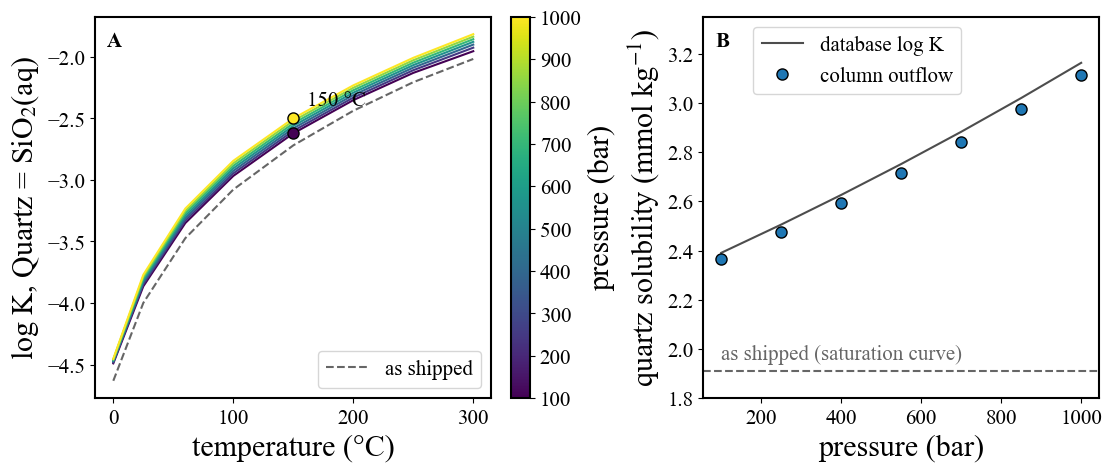

In [5]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)

norm = Normalize(P.min(), P.max())
cmap = plt.get_cmap('viridis')

axA.plot(temperatures, tabulated, linestyle='--', color='0.4', label='as shipped')
for p, row in zip(P, log_k):
    axA.plot(temperatures, row, color=cmap(norm(p)))
axA.plot(temperatures[GRID_INDEX], log_k[-1, GRID_INDEX], marker='o', color=cmap(norm(P[-1])))
axA.plot(temperatures[GRID_INDEX], log_k[0, GRID_INDEX], marker='o', color=cmap(norm(P[0])))
axA.annotate('150 °C', (temperatures[GRID_INDEX], log_k[-1, GRID_INDEX]), xytext=(10, 6),
             textcoords='offset points', va='bottom', ha='left')
axA.set_xlabel('temperature (°C)')
axA.set_ylabel('log K, Quartz = SiO$_2$(aq)')
axA.legend(loc='lower right')
axA.text(0.03, 0.96, 'A', transform=axA.transAxes, fontweight='bold', va='top')
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axA)
cbar.set_label('pressure (bar)')

axB.axhline(10.0 ** tabulated[GRID_INDEX] * 1e3, linestyle='--', color='0.4')
axB.annotate('as shipped (saturation curve)', (P.min(), 10.0 ** tabulated[GRID_INDEX] * 1e3),
             xytext=(0, 5), textcoords='offset points', ha='left', va='bottom', color='0.4')
axB.plot(P, predicted * 1e3, color='0.3', label='database log K')
axB.plot(P, outflow * 1e3, marker='o', linestyle='none', label='column outflow')
axB.set_xlabel('pressure (bar)')
axB.set_ylabel('quartz solubility (mmol kg$^{-1}$)')
axB.set_ylim(1.8, 3.35)
axB.legend(loc='upper left', bbox_to_anchor=(0.10, 1.0))
axB.text(0.03, 0.96, 'B', transform=axB.transAxes, fontweight='bold', va='top')

fig.savefig(HERE / 'quartz_pressure_series.png', dpi=200)

## 6. The sweep in a table

In [6]:
summary = pd.DataFrame({
    'run': totcon['file_num'].values,
    'pressure (bar)': P,
    'log K(Quartz) at 150 °C': log_k[:, GRID_INDEX],
    'database (mmol/kg)': predicted * 1e3,
    'outflow (mmol/kg)': outflow * 1e3,
    'saturation (%)': 100 * outflow / predicted,
}).set_index('run')

summary.round(4)

,pressure (bar),log K(Quartz) at 150 °C,database (mmol/kg),outflow (mmol/kg),saturation (%)
run,,,,,
0,100.0,-2.6215,2.3906,2.3645,98.9116
1,250.0,-2.6011,2.5055,2.4760,98.8215
2,400.0,-2.5807,2.6260,2.5929,98.7397
3,550.0,-2.5604,2.7517,2.7151,98.6707
4,700.0,-2.5402,2.8827,2.8425,98.6040
5,850.0,-2.5200,3.0200,2.9759,98.5422
6,1000.0,-2.4999,3.1630,3.1151,98.4848


## 7. Two things to carry away

**The database has no pressure row, so record the pressure yourself.** Omphalos does it in two places —
`run*/logk_settings.json` beside each database, and the `database_logk` group of `conditions.nc` — because a
file recomputed at 1000 bar and one recomputed at saturation are the same size, the same shape, and equally
silent about which they are.

In [7]:
print((HERE / 'run0' / 'logk_settings.json').read_text())
print(xr.open_dataset(CONDITIONS, group='database_logk'))

{
  "pressure": 100.0
}
<xarray.Dataset> Size: 112B
Dimensions:   (file_num: 7)
Coordinates:
  * file_num  (file_num) int64 56B 0 1 2 3 4 5 6
Data variables:
    pressure  (file_num) float64 56B ...


**The edit is surgical, and you can check that it is.** `reactions: ['Quartz']` rewrites one row. Every run's
database is otherwise byte-identical to the template — same species, same stoichiometry, same molecular
weights, same column alignment. Nothing was regenerated, and nothing else moved.

In [8]:
import io

def lines_of(path):
    with io.open(path, newline='') as file:      # the files are CRLF; keep them that way
        return file.readlines()

template = lines_of(HERE / 'datacom.dbs')

for n in totcon['file_num'].values:
    run = lines_of(HERE / f'run{n}' / 'datacom.dbs')
    differing = [i for i, (a, b) in enumerate(zip(template, run)) if a != b]
    assert len(template) == len(run)
    print(f'run{n}: {len(differing)} line(s) differ from the template — {differing}')

print()
print('template: ', template[2619].strip()[:110])
print('run6:     ', lines_of(HERE / 'run6' / 'datacom.dbs')[2619].strip()[:110])

run0: 1 line(s) differ from the template — [2619]
run1: 1 line(s) differ from the template — [2619]
run2: 1 line(s) differ from the template — [2619]
run3: 1 line(s) differ from the template — [2619]
run4: 1 line(s) differ from the template — [2619]
run5: 1 line(s) differ from the template — [2619]
run6: 1 line(s) differ from the template — [2619]

template:  'Quartz'   22.6880  1    1.0000 'SiO2(aq)'   -4.6319    -3.9993    -3.4734    -3.0782    -2.7191    -2.4378   
run6:      'Quartz'   22.6880  1    1.0000 'SiO2(aq)'   -4.4533    -3.7704    -3.2328    -2.8445    -2.4999    -2.2317   


**A wider recomputation mixes two datasets.** `reactions: 'all'` is what a deck with real aqueous speciation
needs, and on this database it is well behaved: it recomputes 824 reactions, adds about 1.5 s a run, and
introduces no no-data values — it actually fills in 58 rows the shipped file had left blank. What it does do is
leave the file part pyGCC and part whatever compiled the original, because reactions pyGCC does not have keep
their tabulated values under `on_unmatched: 'leave'`. That mixture is not wrong, but it is worth knowing about
rather than discovering.